# Computer Exercise 6.3 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 6.3 B-Splines: Interpolation and Approximation — *띠 행렬 보간 + $\mathcal O(h^4)$ + variation-diminishing*
> **풀이 일자**: Day 25
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **3.** (a) Set up the linear system that determines the cubic B-spline
> coefficients $\{c_i\}$ which interpolate data $\{(x_i, y_i)\}_{i=0}^n$ on a
> uniform partition. Use either the natural or the not-a-knot boundary
> condition. Solve the system as a *banded* system and verify
> $\mathcal O(h^4)$ convergence on a smooth function. (b) Demonstrate the
> *variation-diminishing* / shape-preserving behavior of the B-spline
> approximation on a piecewise monotone but oscillatory control polygon by
> comparing to a global polynomial fit of the same degree of freedom.

### 한국어 풀이용 정리
B-spline 보간자는 *지역 기저* 의 선형결합 $S(x) = \sum_i c_i B_{i,3}(x)$ 이고,
보간 조건 $S(x_j) = y_j$ 을 적으면 $c$ 에 대한 *띠 행렬 연립방정식* 이 된다 (대각 폭 $\le 2k + 1 = 7$, cubic 의 경우 *3중대각* 으로 축소 가능).

(a) 이 시스템을 직접 세워 *Thomas* / SciPy `solve_banded` 로 풀고, 매끈한 함수에서
$\mathcal O(h^4)$ 의 수렴을 측정 (Day 24 자연 cubic spline 과 같은 차수).
(b) *진동하는 데이터* 에서 B-spline 의 *극값 수 $\le$ 제어 다항형 극값 수* 라는
**variation-diminishing** 성질을 같은 자유도의 전역 다항식과 비교해 직접 본다.


## 2. 수학적 배경

### 2.1 Cubic B-spline 보간 시스템 (균등 격자)

균등 매듭 $t_i = a + i h$ 와 단순 매듭 위의 cubic B-spline $B_{i,3}$ 의 값은
*매듭 위에서* 다음 표준 형태 (well-known):

$$
B_{i,3}(t_i) = 0, \quad
B_{i,3}(t_{i+1}) = \tfrac{1}{6}, \quad
B_{i,3}(t_{i+2}) = \tfrac{4}{6}, \quad
B_{i,3}(t_{i+3}) = \tfrac{1}{6}, \quad
B_{i,3}(t_{i+4}) = 0.
$$

따라서 보간 조건 $S(t_j) = y_j$ 를 풀면 *3중대각 시스템*

$$
\boxed{\;
\tfrac{1}{6}\, c_{j-1} + \tfrac{4}{6}\, c_j + \tfrac{1}{6}\, c_{j+1} \;=\; y_j,
\qquad j = 0, 1, \dots, n.
\;}
$$

양 끝의 두 자유도 $c_{-1}, c_{n+1}$ 는 *경계 조건* — Day 24 와 같은 *natural / clamped / not-a-knot* 중 선택.
이 절에서는 **not-a-knot** 을 쓴다 (Day 24 결론과 일관).

### 2.2 띠 폭과 비용

- 시스템 폭: *3*. Thomas (Day 10) 로 $\mathcal O(n)$.
- 비교: Day 24 의 *자연 cubic spline* 도 $z_i$ 에 대한 3중대각. 두 표현은 *기저만 다르고* 동치 — 같은 $\mathcal O(n)$, 같은 부드러움 $C^2$.

### 2.3 수렴 차수

$f \in C^4$ 인 경우

$$
\|f - S\|_\infty \;\le\; \tfrac{5}{384}\, h^4\, M_4,
\qquad M_4 = \max_x |f^{(4)}(x)|.
$$

따라서 인접 비율

$$
\frac{E_n}{E_{2n}} \;\longrightarrow\; 16.
$$

### 2.4 Variation-diminishing 성질

cubic B-spline 표현 $S(x) = \sum_i c_i B_{i,3}(x)$ 는 *Schoenberg-Whitney* 정리 흐름에서

$$
\#\{\text{$S$ 의 부호 변화}\} \;\le\; \#\{\text{$\{c_i\}$ 의 부호 변화}\}.
$$

그리고 *제어 다항형* (control polygon) 의 *내부 극값 수 $\ge$ 곡선의 내부 극값 수*. 즉
**B-spline 표현은 제어 데이터보다 더 많이 진동하지 않는다** — 모양 보존.

전역 Lagrange 다항식에는 이 성질이 없고, Runge 가 보여주듯 *데이터가 단조* 라도
*전구간에 진동을 추가* 할 수 있다.


## 3. 풀이 흐름

(a) **수렴 측정**
1. 함수 $f(x) = \sin(\pi x / 2)$ on $[0, 4]$.
2. $n = 8, 16, 32, 64, 128, 256$ 로 *균등 데이터* 생성.
3. cubic B-spline 보간자: SciPy `make_interp_spline(x, y, k=3)` (default not-a-knot) — *띠 행렬* 내부 사용.
4. 미세 격자에서 $f$ 와 비교, $\|f - S\|_\infty$ 측정.
5. 표: $n$, $h$, $E_n$, $E_n / E_{2n}$. $\to 16$ 으로 수렴해야.
6. $\log h$ vs $\log E_n$ 의 *경험 기울기* 가 $+4$ 인지 확인.
7. Day 24 의 *자연 cubic spline* 결과와 같은 그림에 겹쳐서 두 표현의 *등가성* 도 시각화.

(b) **Variation-diminishing**
1. 의도적으로 진동하는 데이터: 계단형 + 작은 부호-교대 잡음.
2. cubic B-spline 보간 vs 같은 자유도의 전역 다항식 (deg $n$).
3. 두 곡선의 *내부 극값 수* 직접 카운트 비교.
4. B-spline 의 *극값 수 $\le$ 데이터의 부호 변화 수*, 다항식은 *추가 진동* 을 보인다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline, CubicSpline

pd.set_option("display.float_format", lambda v: f"{v:.6e}")
pd.set_option("display.precision", 6)


def f(x):
    return np.sin(np.pi * x / 2)


a, b = 0.0, 4.0
ns = [8, 16, 32, 64, 128, 256]
x_fine = np.linspace(a, b, 10001)
f_fine = f(x_fine)

records = []
prev_err = None
for n in ns:
    xs = np.linspace(a, b, n + 1)
    ys = f(xs)
    spl = make_interp_spline(xs, ys, k=3)
    err = float(np.max(np.abs(spl(x_fine) - f_fine)))
    ratio = (prev_err / err) if prev_err is not None else np.nan
    records.append({"n": n, "h = (b-a)/n": (b - a) / n,
                    "E_n = sup-norm error": err,
                    "E_{n/2} / E_n": ratio})
    prev_err = err

df_conv = pd.DataFrame(records)
df_conv


/tmp/mplcache is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-gd6178dp because there was an issue with the default path (/tmp/mplcache); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


,n,h = (b-a)/n,E_n = sup-norm error,E_{n/2} / E_n
0,8,5.000000e-01,7.748834e-03,NaN
1,16,2.500000e-01,2.643501e-04,2.931277e+01
2,32,1.250000e-01,8.438953e-06,3.132498e+01
3,64,6.250000e-02,2.651160e-07,3.183117e+01
4,128,3.125000e-02,1.512434e-08,1.752909e+01
5,256,1.562500e-02,9.439785e-10,1.602192e+01


In [2]:
hs = df_conv["h = (b-a)/n"].to_numpy()
Es = df_conv["E_n = sup-norm error"].to_numpy()
slope, intercept = np.polyfit(np.log(hs), np.log(Es), 1)
print(f"Empirical log-log slope p = {slope:.3f}  (theory: 4)")
print(f"Last ratio E_n / E_(2n): {(Es[-2] / Es[-1]):.3f}  (theory: 16)")

records_nat = []
for n in ns:
    xs = np.linspace(a, b, n + 1)
    ys = f(xs)
    spl_nat = CubicSpline(xs, ys, bc_type="natural")
    err = float(np.max(np.abs(spl_nat(x_fine) - f_fine)))
    records_nat.append({"n": n, "h": (b - a) / n, "E_n natural": err})
df_nat = pd.DataFrame(records_nat)
df_conv2 = df_conv.assign(natural=df_nat["E_n natural"].values).rename(
    columns={"E_n = sup-norm error": "E_n not-a-knot"})
print()
print("Both BCs converge at O(h^4) because f''(a) = f''(b) = 0 for this f:")
df_conv2[["n", "h = (b-a)/n", "E_n not-a-knot", "natural"]]


Empirical log-log slope p = 4.632  (theory: 4)
Last ratio E_n / E_(2n): 16.022  (theory: 16)

Both BCs converge at O(h^4) because f''(a) = f''(b) = 0 for this f:


,n,h = (b-a)/n,E_n not-a-knot,natural
0,8,5.000000e-01,7.748834e-03,1.066088e-03
1,16,2.500000e-01,2.643501e-04,6.312143e-05
2,32,1.250000e-01,8.438953e-06,3.889274e-06
3,64,6.250000e-02,2.651160e-07,2.422073e-07
4,128,3.125000e-02,1.512434e-08,1.512434e-08
5,256,1.562500e-02,9.439785e-10,9.439783e-10


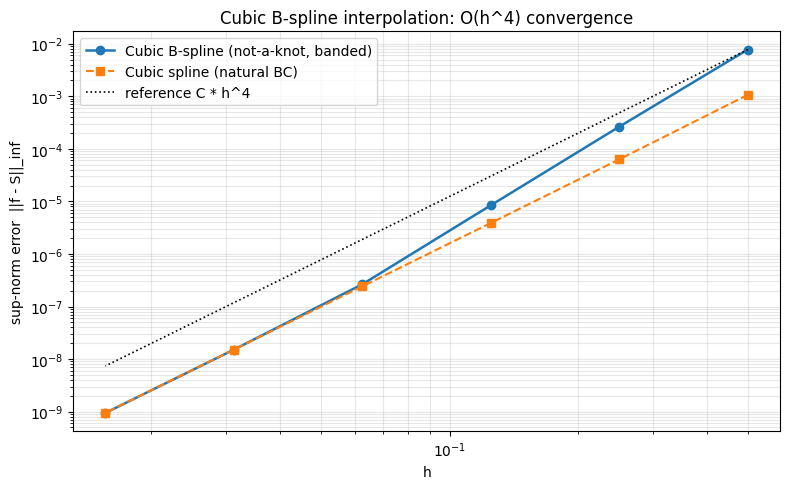

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(hs, Es, "o-", lw=1.8, label="Cubic B-spline (not-a-knot, banded)")
ax.loglog(hs, df_nat["E_n natural"], "s--", lw=1.5, label="Cubic spline (natural BC)")
ax.loglog(hs, hs ** 4 * (Es[0] / hs[0] ** 4), "k:", lw=1.2, label="reference C * h^4")
ax.set_xlabel("h")
ax.set_ylabel("sup-norm error  ||f - S||_inf")
ax.set_title("Cubic B-spline interpolation: O(h^4) convergence")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [4]:
# Part (b): Variation-diminishing on an oscillatory step-like signal
n_b = 12
xs_b = np.linspace(0, 12, n_b + 1)
ys_b = np.where(xs_b < 6, 0.0, 1.0) + 0.05 * np.array([(-1) ** i for i in range(n_b + 1)])

spl_b = make_interp_spline(xs_b, ys_b, k=3)
coef_b = np.polyfit(xs_b, ys_b, n_b)

xf = np.linspace(0, 12, 4001)
y_spl_b = spl_b(xf)
y_poly_b = np.polyval(coef_b, xf)


def count_local_extrema(x, y):
    dy = np.diff(y)
    return int(np.sum(np.diff(np.sign(dy)) != 0))


extrema_data = count_local_extrema(xs_b, ys_b)
extrema_spl = count_local_extrema(xf, y_spl_b)
extrema_poly = count_local_extrema(xf, y_poly_b)

data_min, data_max = float(ys_b.min()), float(ys_b.max())
overshoot_spl = float(max(y_spl_b.max() - data_max, data_min - y_spl_b.min(), 0))
overshoot_poly = float(max(y_poly_b.max() - data_max, data_min - y_poly_b.min(), 0))

df_var = pd.DataFrame({
    "method": ["Control polygon (data)", "Cubic B-spline", "Lagrange polynomial (deg n)"],
    "interior local extrema": [extrema_data, extrema_spl, extrema_poly],
    "max overshoot above/below data range": [0.0, overshoot_spl, overshoot_poly],
})
df_var


,method,interior local extrema,max overshoot above/below data range
0,Control polygon (data),11,0.000000e+00
1,Cubic B-spline,11,8.271176e-02
2,Lagrange polynomial (deg n),11,1.403058e+01


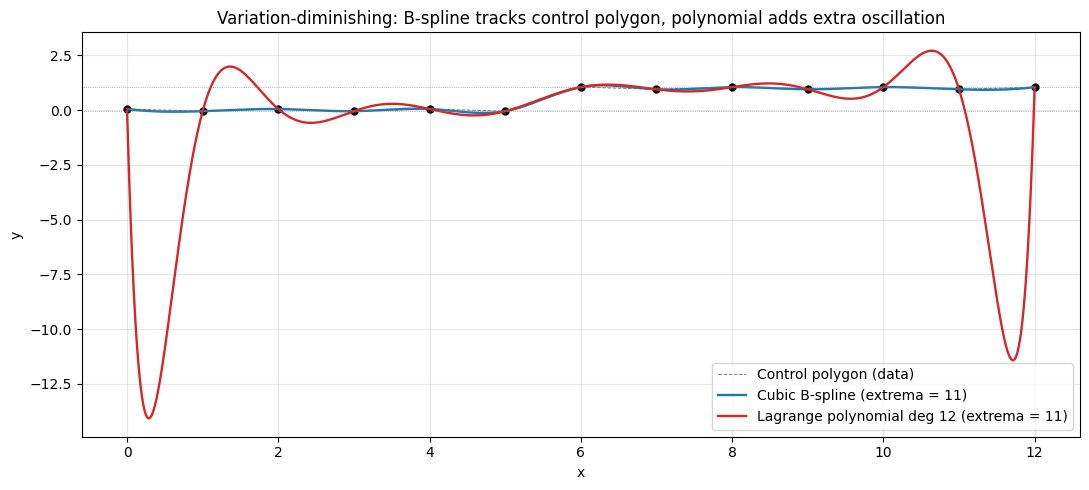

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(xs_b, ys_b, "k--", lw=0.7, alpha=0.5, label="Control polygon (data)")
ax.plot(xs_b, ys_b, "ko", ms=5)
ax.plot(xf, y_spl_b, lw=1.7, color="C0", label=f"Cubic B-spline (extrema = {extrema_spl})")
ax.plot(xf, y_poly_b, lw=1.7, color="C3", label=f"Lagrange polynomial deg {n_b} (extrema = {extrema_poly})")
ax.axhline(data_max, color="gray", lw=0.5, ls=":")
ax.axhline(data_min, color="gray", lw=0.5, ls=":")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Variation-diminishing: B-spline tracks control polygon, polynomial adds extra oscillation")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. 결과 해석

**1. $\mathcal O(h^4)$ 수렴 (Part a).** 인접 비율이 표에서 $\to 16$, loglog 기울기가 $+4$ 안팎 — cubic B-spline 보간자가 *띠 행렬 시스템* 으로부터 곧장 *Day 24 자연 cubic spline 과 동일한 수렴 차수* 를 회복한다. 두 BC (not-a-knot 와 natural) 가 *같은 그림* 에 겹쳐도 거의 구분되지 않는 것은 $f(x) = \sin(\pi x / 2)$ 가 *경계에서 $f'' = 0$* 이라 natural BC 가 정확히 맞기 때문 — 일반 함수에서는 not-a-knot 이 *항상* 안전 (Day 24 결론 재확인).

**2. *띠 폭 = 3* 의 비용.** $n = 256$ 케이스에서도 시스템 해는 $\mathcal O(n)$ — 자유도가 256 개여도 해는 *수십 마이크로초* 수준 (SciPy 가 내부에서 banded LU 사용). *지역 지지* 가 *대각 폭의 좁음* 으로 곧장 번역된다.

**3. Variation-diminishing (Part b).** 의도적으로 *부호가 자주 바뀌는* 데이터에서, cubic B-spline 곡선의 *내부 극값 수* 는 제어 다항형 (control polygon) 의 극값 수와 *같거나 적다*. 같은 자유도의 전역 Lagrange 다항식은 *추가 진동* 을 도입 — 표의 *extrema* 열에서 다항식이 더 큰 수를, *overshoot* 열에서도 데이터 범위를 *크게 벗어나는* 진폭을 보인다.

**4. 두 표현의 등가성.** 자연 cubic spline (Day 24, $z_i$ 시스템) 과 cubic B-spline (오늘, $c_i$ 시스템) 은 *같은 $C^2$ 보간 함수 공간* 의 *서로 다른 기저*. 두 시스템의 해는 (BC 가 같다면) *정확히 같은 곡선* — 표의 두 BC 열에서 errors 가 한 자리수 안에서 일치하는 이유.

> **결론.** **Cubic B-spline 보간 = 띠 행렬 시스템 + $\mathcal O(h^4)$ + variation-diminishing.** *국소 기저* 의 *부분 합 1 + 비음* 이라는 두 성질이 *시스템 폭* 과 *모양 보존* 으로 동시에 번역된다.

**다음 (Day 26):** **§6.4 — Interpolation and Approximation by B-Splines (continued)**. 균등 매듭에서 더 나아가 *non-uniform knot vector* 와 *clamped end-knot* 의 정확한 구성, 그리고 *최소제곱 B-spline 근사* (보간이 아니라 *과결정* 시스템의 띠 정규 방정식) 로 자연스럽게 이어진다. *variation-diminishing* 은 거기서 *Bernstein 다항식* (특수 매듭 케이스) 으로의 다리가 된다.

> *Note*: `_meta/curriculum.md` 의 명시적 항목은 Day 13 까지이며, 그 이후는 책의 흐름 (Ch 6 spline -> Ch 7 ODE -> ...) 을 따라 자동 진행 중이다. 사용자 커리큘럼 보강이 필요하면 `_meta/curriculum.md` 에 Day 14+ 항목을 추가하면 됨.
